In [12]:
# Import Libraries:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/Final_Master_Dataset.csv')
df.head()

,Country,Year,D_Expenditure_GDP,Conflict_Intensity,Health_Expenditure_(% of GDP),Education_Expenditure_(% of GDP),Environmental impact (CO2e/capita),Refugees,Asylum Seekers,Total number of deaths,Population,GDP_Growth_Annual,GDP_PerCapita_Growth_Annual,GDP_Current_USDollars,Inflation_Annual,Unemployment_Total_of_TLF,Unemployment_Male_of_TMF,Unemployment_Female_of_TFF
0,USA,1994,4.215265,NaN,NaN,NaN,19.83,364,0,0,263126000,4.029023,2.761109,7.290000e+12,2.607442,6.119,6.174,6.052
1,USA,1995,3.860246,NaN,NaN,NaN,19.79,243,0,0,266278000,2.684431,1.468929,7.640000e+12,2.805420,5.650,5.633,5.671
2,USA,1996,3.554982,NaN,NaN,NaN,20.14,141,0,0,269394000,3.772773,2.572464,8.070000e+12,2.931204,5.451,5.435,5.470
3,USA,1997,3.554982,NaN,NaN,NaN,20.90,75,0,0,272657000,4.447128,3.197166,8.580000e+12,2.337690,5.000,4.938,5.075
4,USA,1998,3.201558,NaN,NaN,NaN,20.83,50,0,0,275854000,4.483133,3.272230,9.060000e+12,1.552279,4.511,4.419,4.623


In [13]:
# Use only the required features for the model:
features = [
    "Country",
    "Year",
    "D_Expenditure_GDP",
    "Refugees",
    "Asylum Seekers",
    "Total number of deaths",
    "Population",
    "GDP_Growth_Annual",
    "GDP_PerCapita_Growth_Annual",
    "GDP_Current_USDollars",
    "Inflation_Annual",
    "Unemployment_Total_of_TLF",
    "Unemployment_Male_of_TMF",
    "Unemployment_Female_of_TFF"
]

df = df[features]
df.head()


,Country,Year,D_Expenditure_GDP,Refugees,Asylum Seekers,Total number of deaths,Population,GDP_Growth_Annual,GDP_PerCapita_Growth_Annual,GDP_Current_USDollars,Inflation_Annual,Unemployment_Total_of_TLF,Unemployment_Male_of_TMF,Unemployment_Female_of_TFF
0,USA,1994,4.215265,364,0,0,263126000,4.029023,2.761109,7.290000e+12,2.607442,6.119,6.174,6.052
1,USA,1995,3.860246,243,0,0,266278000,2.684431,1.468929,7.640000e+12,2.805420,5.650,5.633,5.671
2,USA,1996,3.554982,141,0,0,269394000,3.772773,2.572464,8.070000e+12,2.931204,5.451,5.435,5.470
3,USA,1997,3.554982,75,0,0,272657000,4.447128,3.197166,8.580000e+12,2.337690,5.000,4.938,5.075
4,USA,1998,3.201558,50,0,0,275854000,4.483133,3.272230,9.060000e+12,1.552279,4.511,4.419,4.623


In [14]:
# Standarize column names:
df.columns = [
    "Country",
    "Year",
    "Defense_GDP",
    "Refugees",
    "Asylum_Seekers",
    "Deaths",
    "Population",
    "GDP_Growth",
    "GDP_PC_Growth",
    "GDP_Current_USD",
    "Inflation",
    "Unemp_Total",
    "Unemp_Male",
    "Unemp_Female"
]

# Sort by country and year for LSTM modelling:
df = df.sort_values(["Country", "Year"])
df.reset_index(drop=True, inplace=True)
# Handle missing-values:
df = df.groupby("Country").apply(               # Country-wise interpolation..
    lambda x: x.interpolate(method="linear")
).reset_index(drop=True)

df = df.dropna().reset_index(drop=True)

# Verify year ranges:
df.groupby("Country")["Year"].agg(["min", "max"])  # (Min; 1994, Max; 2024)

# Split Train/Test by year:
train_df = df[df["Year"] <= 2020].copy()
test_df  = df[df["Year"] > 2020].copy()

print("Train years:", train_df["Year"].min(), "-", train_df["Year"].max())
print("Test years:", test_df["Year"].min(), "-", test_df["Year"].max())


Train years: 1994 - 2020
Test years: 2021 - 2024


/tmp/ipython-input-151388299.py:24: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  lambda x: x.interpolate(method="linear")
/tmp/ipython-input-151388299.py:24: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  lambda x: x.interpolate(method="linear")
/tmp/ipython-input-151388299.py:24: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  lambda x: x.interpolate(method="linear")
/tmp/ipython-input-151388299.py:24: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  lambda x: x.interpolate(method="linear")
/tmp

In [15]:
# Define Inputs vs Targets:
input_features = [
    "Defense_GDP",
    "Refugees",
    "Asylum_Seekers",
    "Deaths",
    "Population",
    "GDP_PC_Growth",
    "GDP_Current_USD",
    "Unemp_Male",
    "Unemp_Female"
]

target_features = [
    "GDP_Growth",
    "Inflation",
    "Unemp_Total"
]

# Final Sanity Check:
print("INPUT SHAPE:", train_df[input_features].shape , "\n\nINPUT FEATURES:" , train_df[input_features])
print("TARGET SHAPE:", train_df[target_features].shape , "\n\nTARGET FEATURES:" , train_df[target_features])



INPUT SHAPE: (135, 9) 

INPUT FEATURES:      Defense_GDP  Refugees  Asylum_Seekers  Deaths  Population  GDP_PC_Growth  \
0       1.693480    113908               0       0  1191835000      11.801890   
1       1.686234    104691               0       0  1204855000       9.832961   
2       1.652727    105806               0       0  1217550000       8.829514   
3       1.632651    106731               0       4  1230075000       8.174846   
4       1.655081    109396               0       0  1241935000       6.890190   
..           ...       ...             ...     ...         ...            ...   
146     3.402602       302             286       0   324353340       1.022666   
147     3.297724       310            2196       8   326608609       1.750141   
148     3.304001       332            2834       1   328529577       2.364442   
149     3.412158       297            2940       0   330226227       2.056766   
150     3.650514       349            2491       0   331577720      -

In [16]:
from sklearn.preprocessing import MinMaxScaler

X_train_raw = train_df[input_features].values
y_train_raw = train_df[target_features].values

X_test_raw = test_df[input_features].values
y_test_raw = test_df[target_features].values

# Input Feature - Scaling.
X_scaler = MinMaxScaler()
X_train_scaled = X_scaler.fit_transform(X_train_raw)
X_test_scaled = X_scaler.transform(X_test_raw)

# Target Feature - Scaling. ( Allows multi-output forecasting later..)
y_scaler = MinMaxScaler()
y_train_scaled = y_scaler.fit_transform(y_train_raw)
y_test_scaled = y_scaler.transform(y_test_raw)

train_scaled_df = train_df.copy()
test_scaled_df = test_df.copy()

train_scaled_df[input_features] = X_train_scaled
train_scaled_df[target_features] = y_train_scaled

test_scaled_df[input_features] = X_test_scaled
test_scaled_df[target_features] = y_test_scaled

# LSTM - Sequence Function. (Per Country)
def create_sequences_per_country(df, input_cols, target_cols, time_steps=5):
    X, y = [], []

    for country in df["Country"].unique():
        country_df = df[df["Country"] == country].sort_values("Year")

        data_X = country_df[input_cols].values
        data_y = country_df[target_cols].values

        for i in range(len(country_df) - time_steps):
            X.append(data_X[i:i+time_steps])
            y.append(data_y[i+time_steps])

    return np.array(X), np.array(y)


# LSTM Sequences.
TIME_STEPS = 5  #Time window = 5...

X_train_seq, y_train_seq = create_sequences_per_country(
    train_scaled_df,
    input_features,
    target_features,
    TIME_STEPS
)

X_test_seq, y_test_seq = create_sequences_per_country(
    test_scaled_df,
    input_features,
    target_features,
    TIME_STEPS
)

print("X_train_seq shape:", X_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)

print("\n\nX_test_seq shape:", X_test_seq.shape)
print("y_test_seq shape:", y_test_seq.shape)



# Sanity-Check:
assert X_train_seq.shape[0] == y_train_seq.shape[0]
assert X_test_seq.shape[0] == y_test_seq.shape[0]




X_train_seq shape: (110, 5, 9)
y_train_seq shape: (110, 3)


X_test_seq shape: (0,)
y_test_seq shape: (0,)


X_train_seq: (110, 5, 9)
y_train_seq: (110, 3)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 5, 64)          │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,459 (122.89 KB)

 Trainable params: 31,459 (122.89 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - loss: 0.1548 - val_loss: 0.0606
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0751 - val_loss: 0.0221
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0259 - val_loss: 0.0427
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0269 - val_loss: 0.0324
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0250 - val_loss: 0.0184
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0197 - val_loss: 0.0203
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0236 - val_loss: 0.0184
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0167 - val_loss: 0.0175
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0184 - val_loss: 0.0175
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0173 - val_loss: 0.0185
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0142 - val_loss: 0.0197
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0152 - val_loss: 0.0181
E

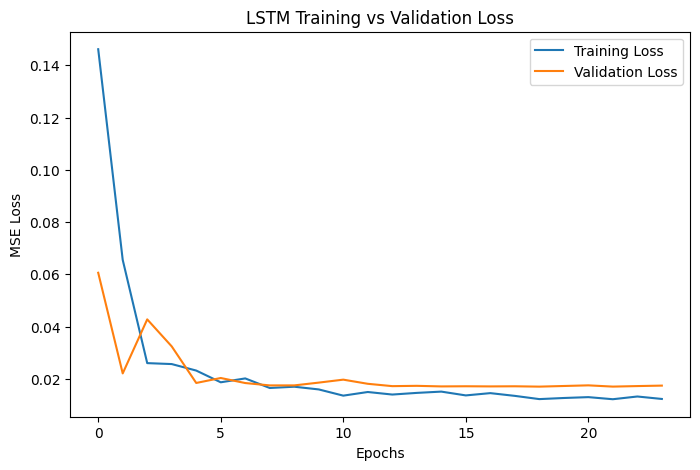

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Confirm Input Shapes.
print("X_train_seq:", X_train_seq.shape)
print("y_train_seq:", y_train_seq.shape)

# LSTM Architecture:
model = Sequential()

# 1st layer:
model.add(
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])
    )
)
model.add(Dropout(0.2))

# 2nd Layer:
model.add(LSTM(units=32))
model.add(Dropout(0.2))

# Output layer:
model.add(Dense(len(target_features)))

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

# 1st LSTM layer for return sequences for stacking..
# Output layer -> 3 neurons for 3 targets..

# Should add EarlyStopping incase for over-training:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Train:
history = model.fit(
    X_train_seq,
    y_train_seq,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Plot Validation vs Training:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("LSTM Training vs Validation Loss")
plt.legend()
plt.show()


In [20]:
# Prepare Rolling Forecasting seeds. (For Training)
# Goal: Each country will get its own forecasting-memory.
forecast_seeds = {}
countries = train_scaled_df["Country"].unique()

for country in countries:
    country_df = train_scaled_df[train_scaled_df["Country"] == country].sort_values("Year")
    last_sequence = country_df[input_features].values[-TIME_STEPS:]
    forecast_seeds[country] = last_sequence

# Function for rolling-forecasting:
def rolling_forecast(model,seed_sequence,n_years,y_scaler):
    forecasts = []
    current_sequence = seed_sequence.copy()

    for _ in range(n_years):
        # Predict next year (scaled):
        pred_scaled = model.predict(current_sequence[np.newaxis, :, :], verbose=0)

        # values -> real values:
        pred_real = y_scaler.inverse_transform(pred_scaled)[0]
        forecasts.append(pred_real)

        # Update sequence:
        current_sequence = np.roll(current_sequence, -1, axis=0)
        current_sequence[-1, :len(pred_scaled[0])] = pred_scaled[0]

    return np.array(forecasts)


# Now the time to forecast 2021-2024 for each country:
forecast_horizon = 4  # 2021–2024

all_results = []

for country in countries:
    preds = rolling_forecast(
        model,
        forecast_seeds[country],
        forecast_horizon,
        y_scaler
    )

    years = list(range(2021, 2021 + forecast_horizon))

    for i, year in enumerate(years):
        all_results.append([
            country,
            year,
            preds[i][0],  # GDP Growth
            preds[i][1],  # Inflation
            preds[i][2],  # Unemployment
        ])

# Forecast results Data-frame:
forecast_df = pd.DataFrame(
    all_results,
    columns=[
        "Country",
        "Year",
        "GDP_Growth_Pred",
        "Inflation_Pred",
        "Unemp_Pred"
    ]
)

forecast_df.head()

# Merge with actual data for Evaluation:
actual_df = df[
    (df["Year"] >= 2021) & (df["Year"] <= 2024)
][[
    "Country",
    "Year",
    "GDP_Growth",
    "Inflation",
    "Unemp_Total"
]]

results_df = forecast_df.merge(
    actual_df,
    on=["Country", "Year"],
    how="left"
)

# Evaluation Metrics:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

metrics = {}

for target, pred_col, act_col in [
    ("GDP_Growth", "GDP_Growth_Pred", "GDP_Growth"),
    ("Inflation", "Inflation_Pred", "Inflation"),
    ("Unemployment", "Unemp_Pred", "Unemp_Total")
]:
    mae = mean_absolute_error(results_df[act_col], results_df[pred_col])
    rmse = np.sqrt(mean_squared_error(results_df[act_col], results_df[pred_col]))

    metrics[target] = {"MAE": mae, "RMSE": rmse}
    print(f"{target} → MAE: {mae:.4f}, RMSE: {rmse:.4f}")



GDP_Growth → MAE: 3.6256, RMSE: 4.3465
Inflation → MAE: 4.9141, RMSE: 5.8847
Unemployment → MAE: 0.8202, RMSE: 1.1346


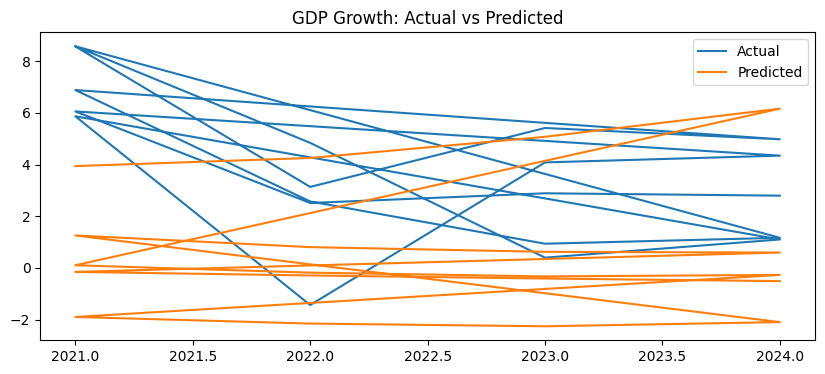

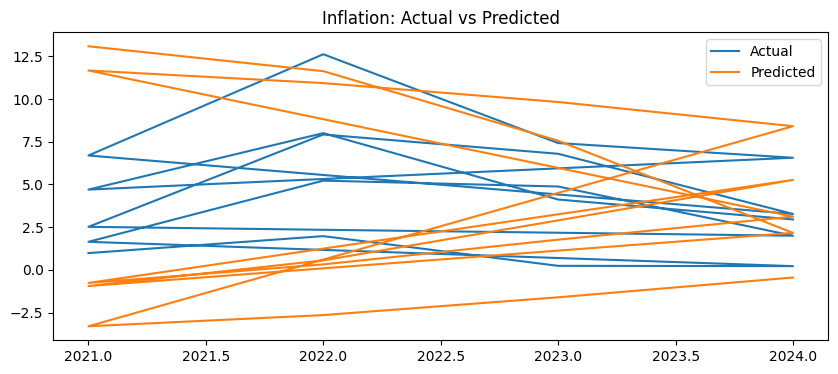

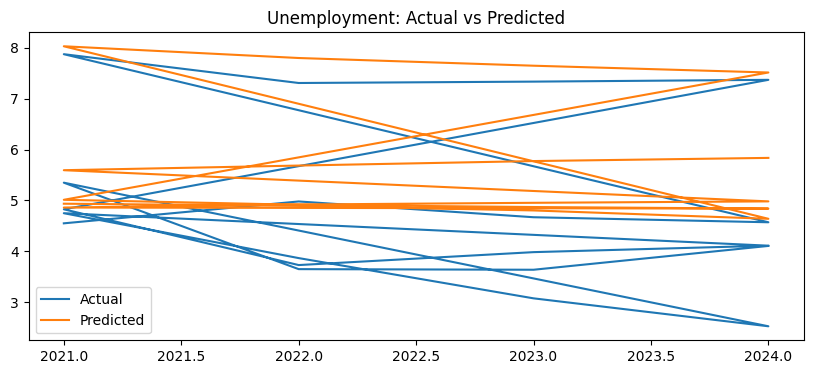

In [21]:
# Plot "Actual" vs "Predicted":
# GDP-Growth:
plt.figure(figsize=(10,4))
plt.plot(results_df["Year"], results_df["GDP_Growth"], label="Actual")
plt.plot(results_df["Year"], results_df["GDP_Growth_Pred"], label="Predicted")
plt.title("GDP Growth: Actual vs Predicted")
plt.legend()
plt.show()
print("\n")

# Inflation:
plt.figure(figsize=(10,4))
plt.plot(results_df["Year"], results_df["Inflation"], label="Actual")
plt.plot(results_df["Year"], results_df["Inflation_Pred"], label="Predicted")
plt.title("Inflation: Actual vs Predicted")
plt.legend()
plt.show()
print("\n")

# Unemployment:
plt.figure(figsize=(10,4))
plt.plot(results_df["Year"], results_df["Unemp_Total"], label="Actual")
plt.plot(results_df["Year"], results_df["Unemp_Pred"], label="Predicted")
plt.title("Unemployment: Actual vs Predicted")
plt.legend()
plt.show()
